In [1]:
from netCDF4 import Dataset
from datetime import *
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from glob import glob
# from mpl_toolkits.basemap import Basemap
import seawater as sw
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from scipy.linalg import *
import seaborn as sns
from scipy.ndimage.filters import gaussian_filter as gfilter
from lietal import uv2psiphi
# import time
# sys.path.append('/home/igor/Dropbox/Mestrado/Scripts/master/iury_wg/');
# from functions.lietal import uv2psiphi
from scipy.interpolate import griddata



In [2]:
pwd

'/Users/iufarias/Documents/MSc/Scripts/Eddy_Detect'

In [3]:

'Plotagem de climatologias'

bvar=Dataset('/Users/iufarias/Documents/MSc/altdata/clim/etopo1_bedrock.nc')
lonb=bvar['lon'][:];latb=bvar['lat'][:];bat=bvar['Band1'][:]
lonb,latb=np.meshgrid(lonb,latb)



var=Dataset('/Users/iufarias/Documents/MSc/altdata/clim/adt_climatology.nc')
avar=Dataset('/Users/iufarias/Documents/MSc/altdata/clim/sla_climatology.nc')



In [4]:

ttime=[datetime(1950,1,1) + timedelta(days=np.int(dia)) for dia in var['time'][:].data]
ttime=pd.DatetimeIndex(ttime);

# right cut for the area
amask=var['adt'][:,11:,:].mask
adt=var['adt'][:,11:,:].data
adt[amask]=np.nan;
lat=var['latitude'][11:]
lon=var['longitude'][:]-360
dx,dy=np.diff(lon).mean()*111e3,np.diff(lat).mean()*111e3
lon,lat=np.meshgrid(lon,lat)

slamask=avar['sla'][:,11:,:].mask
sla=avar['sla'][:,11:,:].data
sla[slamask]=np.nan;

mdt=adt-sla
mdt=np.nanmean(mdt,axis=0)

<ipython-input-4-a1faac486a93>:1: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ttime=[datetime(1950,1,1) + timedelta(days=np.int(dia)) for dia in var['time'][:].data]
<ipython-input-4-a1faac486a93>:18: RuntimeWarning: Mean of empty slice
  mdt=np.nanmean(mdt,axis=0)


In [5]:

hm=np.nanmean(adt,axis=0)



ux=-(9.8/sw.f(lat.data))*np.gradient(hm,axis=0)/dy
vx=(9.8/sw.f(lat.data))*np.gradient(hm,axis=1)/dx
u=ux.copy();v=vx.copy()
bb=10

lonbx,latbx,batx=lonb[::bb,::bb],latb[::bb,::bb],bat[::bb,::bb]

meth='linear'
ui=griddata((lon[~np.isnan(ux)],lat[~np.isnan(ux)]),ux[~np.isnan(ux)],(lonbx,latbx),method=meth);
vi=griddata((lon[~np.isnan(vx)],lat[~np.isnan(vx)]),vx[~np.isnan(vx)],(lonbx,latbx),method=meth);

ui[np.isnan(ui)]=0;
vi[np.isnan(vi)]=0;

ui[batx>=-400]=0;
vi[batx>=-400]=0;



psix,und,vnd,_,_,_=uv2psiphi(lonbx,latbx,ui,vi)
psix=psix-np.nanmean(psix)

psix[np.isnan(ui)]=np.nan;
und[np.isnan(ui)]=np.nan;
vnd[np.isnan(vi)]=np.nan;


mdt=adt-sla
mdt=np.nanmean(mdt,axis=0)

<ipython-input-5-352a05952715>:1: RuntimeWarning: Mean of empty slice
  hm=np.nanmean(adt,axis=0)
<ipython-input-5-352a05952715>:33: RuntimeWarning: Mean of empty slice
  mdt=np.nanmean(mdt,axis=0)


<ipython-input-17-37474a180bbb>:35: UserWarning: The following kwargs were not used by contour: 'latlon'
  plt.contourf(lonb,latb,bat,levels=[-150,np.inf],colors='dimgray',alpha=1,latlon=True,zorder=14)
<ipython-input-17-37474a180bbb>:36: UserWarning: The following kwargs were not used by contour: 'linewidth', 'latlon'
  plt.contour(lonb,latb,-bat,levels=[150],colors='k',alpha=1,linewidth=1,latlon=True,zorder=15)
<ipython-input-17-37474a180bbb>:37: UserWarning: The following kwargs were not used by contour: 'latlon', 'linewidhts', 'zoder'
  plt.contour(lonb,latb,-bat,levels=[-np.inf,150],colors='k',alpha=1,latlon=True,linewidhts=0.5,zoder=16)
<ipython-input-17-37474a180bbb>:38: UserWarning: The following kwargs were not used by contour: 'latlon'
  plt.contourf(lonb,latb,-bat,levels=[-np.inf,0],colors='#fecf78',alpha=1,latlon=True,zorder=14)
<ipython-input-17-37474a180bbb>:39: UserWarning: The following kwargs were not used by contour: 'latlon', 'linewidth'
  plt.contour(lonb,latb,-bat,

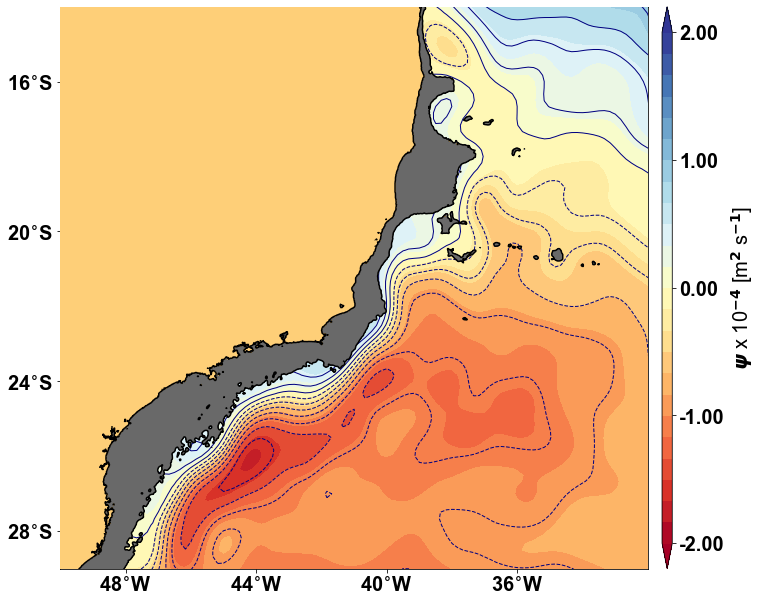

In [17]:



'FIGURA 1: CLIM V GEOST. PSI'

plt.rcParams['font.size']=20
plt.rcParams['font.sans-serif']='Arial'
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.weight']='bold'
ltmn=-29;ltmx=-10;lnmn=-52;lnmx=-32.

p=plt.figure(figsize=(11.17,  8.77))
lbs=[True, False,False,True]
# C = Basemap(llcrnrlon=-49.5,llcrnrlat=-28,urcrnrlat=-23,urcrnrlon=-43.5,resolution='h',projection='merc')
# C = Basemap(llcrnrlon=lnmn+2,llcrnrlat=ltmn,urcrnrlat=ltmx,urcrnrlon=lnmx,resolution='h',projection='cyl')

# C.drawcoastlines(linewidth=1);

# C.fillcontinents(color='#fecf78',zorder=100)
# C.drawstates(linewidth=0.5,zorder=101)
# C.drawmeridians(np.arange(lnmn,lnmx,4),labels=lbs,zorder=102,linewidth=0.1)
# C.drawparallels(np.arange(ltmn+4,ltmx,4),labels=lbs,zorder=103,linewidth=0.1)

# cc=C.contourf(lon,lat,psix*1e-4,cmap='RdYlBu',levels=np.linspace(-2.5,2.5,25),zorder=10,extend='both')
# C.contour(lon,lat,psix*1e-4,colors='navy',zorder=12,linewidths=1,levels=np.linspace(-2,2,19))

cc=plt.contourf(lonbx,latbx,gfilter(psix,1)*1e-4,cmap='RdYlBu',levels=np.linspace(-2,2,25),zorder=10,extend='both')
plt.contour(lonbx,latbx,gfilter(psix,1)*1e-4,colors='navy',zorder=12,linewidths=1,levels=np.linspace(-2,2,19))

# Q=C.quiver(lon,lat,und,vnd,scale=10)
# plt.quiverkey(Q,0.11,0.9,0.2,r'0.2 m s $^{-1}$')

cbar=plt.colorbar(cc,ticks=np.arange(-2,3),format='%.2f',aspect=50,pad=0.02)
cbar.set_label(r'$\psi$ x 10$^{-4}$ [m$^2$ s$^{-1}$]')
# cbar.set_label(r'$\psi$ x 10$^{-5}$ [m$^2$ s$^{-1}$]')


plt.contourf(lonb,latb,bat,levels=[-150,np.inf],colors='dimgray',alpha=1,latlon=True,zorder=14)
plt.contour(lonb,latb,-bat,levels=[150],colors='k',alpha=1,linewidth=1,latlon=True,zorder=15)
plt.contour(lonb,latb,-bat,levels=[-np.inf,150],colors='k',alpha=1,latlon=True,linewidhts=0.5,zoder=16)
plt.contourf(lonb,latb,-bat,levels=[-np.inf,0],colors='#fecf78',alpha=1,latlon=True,zorder=14)
plt.contour(lonb,latb,-bat,levels=[-np.inf,0],colors='k',alpha=1,latlon=True,linewidth=0.5,zorder=17)

plt.xlim()
plt.ylim(-29,-14)
plt.xlim(-50,-32)
plt.yticks(np.arange(-28,-15,4),[r'28$^{\circ}$S',r'24$^{\circ}$S',r'20$^{\circ}$S',r'16$^{\circ}$S'])
plt.xticks(np.arange(-48,-32,4),[r'48$^{\circ}$W',r'44$^{\circ}$W',r'40$^{\circ}$W',r'36$^{\circ}$W'])



# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.clabel(ctt,fmt='%i',fontsize=10)
plt.tight_layout()

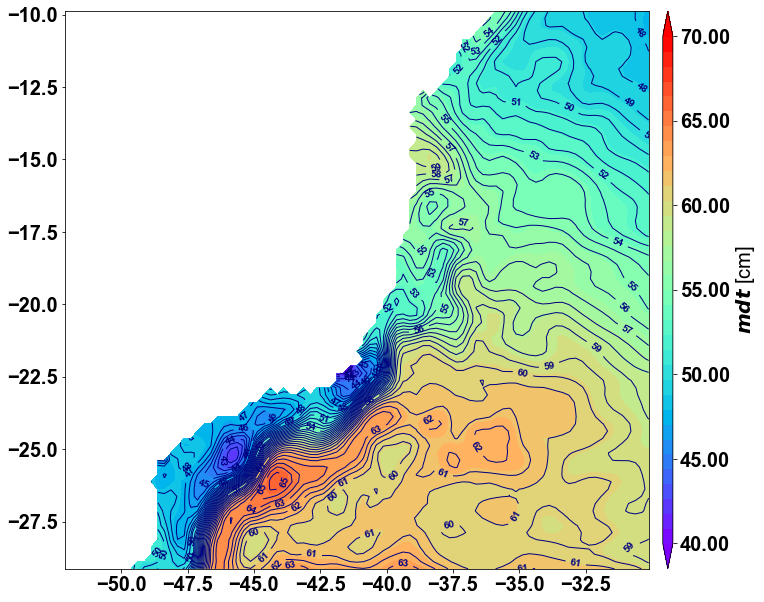

In [61]:

'FIGURA 0: MDT'


plt.rcParams['font.size']=20
plt.rcParams['font.sans-serif']='Arial'
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.weight']='bold'
ltmn=-29;ltmx=-10;lnmn=-52;lnmx=-32.

p=plt.figure(figsize=(11.17,  8.77))
lbs=[True, False,False,True]
# C = Basemap(llcrnrlon=-49.5,llcrnrlat=-28,urcrnrlat=-23,urcrnrlon=-43.5,resolution='h',projection='merc')
# C = Basemap(llcrnrlon=lnmn+2,llcrnrlat=ltmn,urcrnrlat=ltmx,urcrnrlon=lnmx,resolution='h',projection='cyl')

# C.drawcoastlines(linewidth=1);

# C.fillcontinents(color='#fecf78',zorder=100)
# C.drawstates(linewidth=0.5,zorder=101)
# C.drawmeridians(np.arange(lnmn,lnmx,4),labels=lbs,zorder=102,linewidth=0.1)
# C.drawparallels(np.arange(ltmn+4,ltmx,4),labels=lbs,zorder=103,linewidth=0.1)

# cc=C.contourf(lon,lat,-(9.8/sw.f(lat))*(hm-np.nanmean(hm))*1e-5,cmap='RdYlBu',levels=np.linspace(-2.5,2.5,35),zorder=10,extend='both')
# C.contour(lon,lat,(-9.8/sw.f(lat))*(hm-np.nanmean(hm))*1e-5,colors='navy',zorder=12,linewidths=1,levels=np.linspace(-2,2,35))

cc=plt.contourf(lon,lat,mdt*100,cmap='rainbow',levels=np.linspace(40,70,35),extend='both')
ctt=plt.contour(lon,lat,mdt*100,colors='navy',linewidths=1,levels=np.linspace(40,70,45))
cl=plt.clabel(ctt,fmt='%i',fontsize=10)
cl.zorder=13
# Q=C.quiver(lon,lat,und,vnd,scale=10)
# plt.quiverkey(Q,0.11,0.9,0.2,r'0.2 m s $^{-1}$')

cbar=plt.colorbar(cc,ticks=np.arange(-40,80,5),format='%.2f',aspect=50,pad=0.02)
cbar.set_label(r'$mdt$ [cm]')


# C.contourf(lonb,latb,bat,levels=[-150,np.inf],colors='dimgray',alpha=1,latlon=True,zorder=14)
# C.contour(lonb,latb,-bat,levels=[150],colors='k',alpha=1,linewidth=1,latlon=True,zorder=15)
# C.contour(lonb,latb,-bat,levels=[-np.inf,150],colors='k',alpha=1,latlon=True,linewidhts=0.5,zoder=16)
# ctt=C.contour(lonb,latb,-bat,levels=[1e3,2e3,3e3],colors='dimgray',alpha=0.8,latlon=True,linewidths=0.5)

plt.tight_layout()